In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn import preprocessing, svm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
# why didn't this work?
# df = pd.read_csv('https://www.kaggle.com/datasets/dftow001/bottle-csv')

In [4]:
# from https://www.kaggle.com/datasets/dftow001/bottle-csv
df = pd.read_csv("../data/bottle.csv")
df.head()

/tmp/ipykernel_161188/740045103.py:2: DtypeWarning: Columns (47,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/bottle.csv")


,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
0,1,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3,0,10.50,33.440,NaN,25.649,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3,8,10.46,33.440,NaN,25.656,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,054.0 056.0,19-4903CR-HY-060-0930-05400560-0010A-7,10,10.46,33.437,NaN,25.654,NaN,...,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,054.0 056.0,19-4903CR-HY-060-0930-05400560-0019A-3,19,10.45,33.420,NaN,25.643,NaN,...,NaN,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,054.0 056.0,19-4903CR-HY-060-0930-05400560-0020A-7,20,10.45,33.421,NaN,25.643,NaN,...,NaN,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_binary = df[['Salnty', 'T_degC']]

In [6]:
df_binary.columns = ['Sal', 'Temp']
df_binary.head()

,Sal,Temp
0,33.440,10.50
1,33.440,10.46
2,33.437,10.46
3,33.420,10.45
4,33.421,10.45


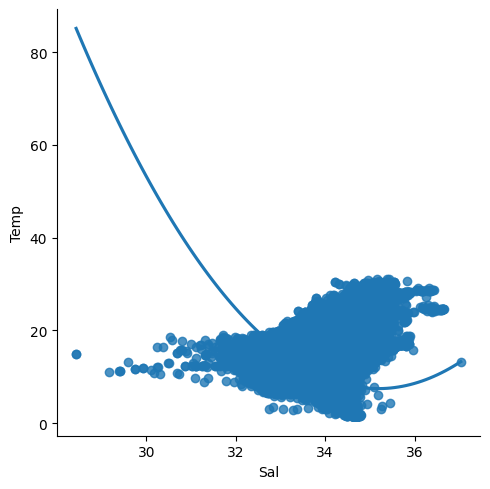

In [7]:
sns.lmplot(x='Sal', y='Temp', data=df_binary, order=2, ci=None)
plt.show()

In [8]:
# Eliminating Nan or missing input numbers
df_binary.ffill(inplace=True)

/tmp/ipykernel_161188/1874653538.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_binary.ffill(inplace=True)


In [9]:
# Training
X = np.array(df_binary['Sal']).reshape(-1, 1)
y = np.array(df_binary['Temp']).reshape(-1, 1)

In [10]:
df_binary.dropna(inplace=True)


/tmp/ipykernel_161188/2087288790.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_binary.dropna(inplace=True)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
regr = LinearRegression()
regr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
print(regr.score(X_test, y_test))

0.20285714260717924


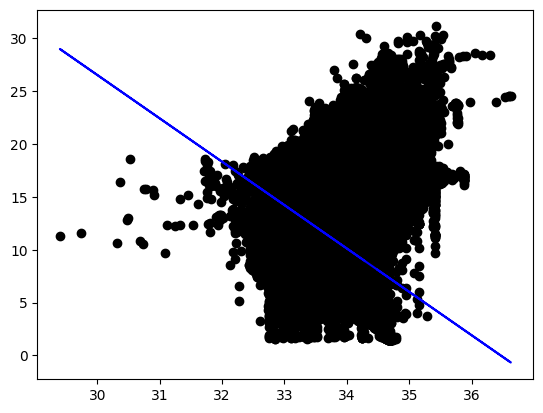

In [14]:
y_pred = regr.predict(X_test)
plt.scatter(X_test, y_test, color='black')
plt.plot(X_test, y_pred, color='blue')
plt.show()

Low accuracy. The model has not fit very well with the existing data. this suggests that our data is not suitable for linear regression. 

# Working with a small dataset

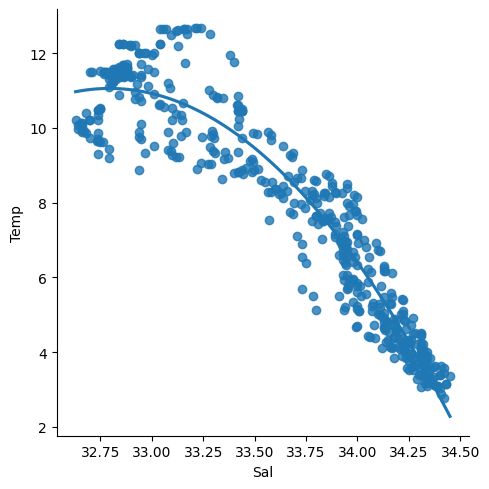

In [15]:
df_binary500 = df_binary[:][:500]

# last 500 rows of the data
sns.lmplot(x='Sal', y='Temp', data=df_binary500, order=2, ci=None)

In [16]:
df_binary500.ffill(inplace=True)

X = np.array(df_binary500['Sal']).reshape(-1, 1)
y = np.array(df_binary500['Temp']).reshape(-1, 1)

df_binary500.dropna(inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

regr = LinearRegression()
regr.fit(X_train, y_train)
print(regr.score(X_test, y_test))

0.8428197557539528


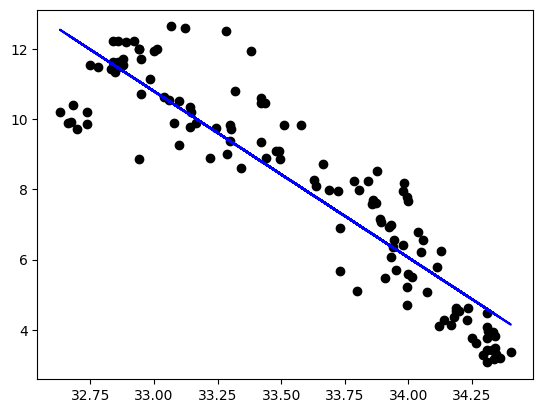

In [17]:
y_pred = regr.predict(X_test)
plt.scatter(X_test, y_test, color='black')
plt.plot(X_test, y_pred, color='blue')
plt.show()

In [18]:
# Evaluation metrics for regression

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
# rmse = mean_squared_error(y_test, y_pred, squared=False) # not working
print(f"MAE: {mae}, MSE: {mse}")

MAE: 0.9131580100211476, MSE: 1.3062508148178922
